<a href="https://colab.research.google.com/github/asmaa-2003/LSTM-Anomaly--detection/blob/main/notebook3_metropt2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 3 — Interpretable Rules for Online Failure Prediction
**Paper:** *Interpretable rules for online failure prediction: a case study on metro do porto datasets*  
Jakobs, Veloso, Gama — IJDSA (2026)

**Dataset:** MetroPT2 (April 28 – July 28, 2022)  
**Known failures (from paper Table 1):**
- Air Leak : 2022-06-04 10:19 → 2022-06-04 14:22 | LPS: 2022-06-04 11:26
- Oil Leak : 2022-07-11 10:10 → 2022-07-14 10:22 | LPS: 2022-07-13 19:43

**Exact paper pipeline:**
1. Temporal split: train (before 2022-06-01), test (from 2022-06-01)
2. LPS excluded from features (paper §2)
3. Normalize per channel (mean/std from train)
4. Sliding windows: L=1800 (30-min), stride d=300 (5-min)
5. Convolutional AE: N=10 blocks, dilation=2^i, 30 kernels, kernel=3, dropout=0.2, embed=32
6. Last 30% of train → validation → estimate τ_anom = β × q99
7. Low-pass filter: z_t = z_{t-1} + α(y_t − z_{t-1})
8. Failure if p(failure) > τ_fail = 0.5
9. Best config (paper Table 3): α=0.05, β=1 → perfect F1=1.0
10. Online Rule-Learning (Algorithm 1): Decision Trees on φ(x)=[var,min,max,mean]
11. Compare vs AMRules, report support & nA

In [ ]:
# ── 0. Installs ────────────────────────────────────────────────────────────
import subprocess, sys
for p in ['tensorflow','scikit-learn','pandas','numpy','matplotlib']:
    subprocess.check_call([sys.executable,'-m','pip','install',p,'--quiet'])
print('Done')

Done


In [ ]:
# ── 1. Imports ─────────────────────────────────────────────────────────────
import warnings, os
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, export_text

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print('Imports OK')

Imports OK


In [ ]:
# ── 2. Load MetroPT2 ───────────────────────────────────────────────────────
CSV = 'MetroPT2.csv'   # ← غيّر المسار إذا لزم

df = pd.read_csv(CSV, parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

print(f'Shape     : {df.shape}')
print(f'Date range: {df.timestamp.min()} → {df.timestamp.max()}')
print(f'Columns   : {df.columns.tolist()}')

Shape     : (7116940, 21)
Date range: 2022-04-28 12:33:29.120000 → 2022-07-28 12:24:34.839000
Columns   : ['timestamp', 'TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Flowmeter', 'Motor_current', 'COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses', 'gpsLat', 'gpsLong', 'gpsSpeed', 'gpsQuality']


In [ ]:
# ── 3. Define known failures (paper Table 1 — MetroPT2) ───────────────────
FAILURES = [
    {
        'name'     : 'Air Leak',
        'start'    : pd.Timestamp('2022-06-04 10:19:24'),
        'end'      : pd.Timestamp('2022-06-04 14:22:39'),
        'lps_time' : pd.Timestamp('2022-06-04 11:26:01'),
        'goal'     : pd.Timestamp('2022-06-04 09:26:01'),  # 2h before LPS
    },
    {
        'name'     : 'Oil Leak',
        'start'    : pd.Timestamp('2022-07-11 10:10:18'),
        'end'      : pd.Timestamp('2022-07-14 10:22:08'),
        'lps_time' : pd.Timestamp('2022-07-13 19:43:52'),
        'goal'     : pd.Timestamp('2022-07-13 17:43:52'),  # 2h before LPS
    }
]

# Create ground-truth failure label from known periods
df['failure_label'] = 0
for f in FAILURES:
    mask = (df['timestamp'] >= f['start']) & (df['timestamp'] <= f['end'])
    df.loc[mask, 'failure_label'] = 1

print('Failure label distribution:')
print(df['failure_label'].value_counts())
print(f'Failure ratio: {df.failure_label.mean()*100:.4f}%')

Failure label distribution:
failure_label
0    6883378
1     233562
Name: count, dtype: int64
Failure ratio: 3.2818%


In [ ]:
# ── 4. Feature selection — paper §2 ───────────────────────────────────────
# LPS: "used neither for training nor testing" → excluded
# GPS columns: not sensor-APU data → excluded
# Flowmeter: INCLUDED (key sensor in paper findings)

FEATURE_COLS = [
    'TP2','TP3','H1','DV_pressure','Reservoirs',
    'Oil_temperature','Flowmeter','Motor_current',
    'COMP','DV_eletric','Towers','MPG',
    'Pressure_switch','Oil_level','Caudal_impulses'
]

# Verify all columns exist
missing = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    print(f'WARNING — missing columns: {missing}')
    FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

print(f'Using {len(FEATURE_COLS)} features: {FEATURE_COLS}')

Using 15 features: ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Oil_temperature', 'Flowmeter', 'Motor_current', 'COMP', 'DV_eletric', 'Towers', 'MPG', 'Pressure_switch', 'Oil_level', 'Caudal_impulses']


In [ ]:
# ── 5. Temporal train/test split — cutoff = 2022-06-01 (paper §5.1) ────────
# Paper: "For MetroPT2 we choose June 1st, 2022 as the cutoff"

CUTOFF = pd.Timestamp('2022-06-01')

df_train = df[df['timestamp'] < CUTOFF].copy()
df_test  = df[df['timestamp'] >= CUTOFF].copy()

print(f'Train: {len(df_train):,} rows | {df_train.timestamp.min()} → {df_train.timestamp.max()}')
print(f'Test : {len(df_test):,} rows  | {df_test.timestamp.min()} → {df_test.timestamp.max()}')
print(f'Train failures: {df_train.failure_label.sum():,}')
print(f'Test  failures: {df_test.failure_label.sum():,}')

Train: 2,658,869 rows | 2022-04-28 12:33:29.120000 → 2022-05-31 23:59:59.966000
Test : 4,458,071 rows  | 2022-06-01 00:00:00.957000 → 2022-07-28 12:24:34.839000
Train failures: 0
Test  failures: 233,562


In [ ]:
# ── 6. Normalisation — fit on train only (paper §5.1) ─────────────────────
train_vals = df_train[FEATURE_COLS].values.astype(np.float32)
test_vals  = df_test[FEATURE_COLS].values.astype(np.float32)

col_means = np.nanmean(train_vals, axis=0)
col_stds  = np.nanstd(train_vals, axis=0)
col_stds[col_stds == 0] = 1.0

# Fill NaN with column mean
for i in range(train_vals.shape[1]):
    train_vals[np.isnan(train_vals[:,i]), i] = col_means[i]
    test_vals[np.isnan(test_vals[:,i]), i]   = col_means[i]

X_train_norm = (train_vals - col_means) / col_stds
X_test_norm  = (test_vals  - col_means) / col_stds

print(f'Train normalised: {X_train_norm.shape}')
print(f'Test  normalised: {X_test_norm.shape}')

Train normalised: (2658869, 15)
Test  normalised: (4458071, 15)


In [ ]:
# ── 7. Sliding windows L=1800 (30-min), stride d=300 (5-min) ─────────────
# Paper §5.1: "overlapping windows of 30 min (L=1800) with a stride of 5 min (d=300)"
# Note: data is ~1Hz so 1800 samples = 30 min

L = 1800
D = 300

def make_windows(X, L, D):
    return np.array([X[i:i+L] for i in range(0, len(X)-L+1, D)],
                    dtype=np.float32)

def window_labels(y, L, D):
    return np.array([int(y[i:i+L].max()) for i in range(0, len(y)-L+1, D)])

def window_timestamps(ts, L, D):
    return np.array([ts[i] for i in range(0, len(ts)-L+1, D)])

y_train_raw = df_train['failure_label'].values
y_test_raw  = df_test['failure_label'].values
ts_train    = df_train['timestamp'].values
ts_test     = df_test['timestamp'].values

W_train      = make_windows(X_train_norm, L, D)
W_test       = make_windows(X_test_norm,  L, D)
y_train_win  = window_labels(y_train_raw, L, D)
y_test_win   = window_labels(y_test_raw,  L, D)
ts_train_win = window_timestamps(ts_train, L, D)
ts_test_win  = window_timestamps(ts_test,  L, D)

ts_test_pd = pd.to_datetime(ts_test_win)

print(f'Train windows: {W_train.shape} | failures: {y_train_win.sum()}')
print(f'Test  windows: {W_test.shape}  | failures: {y_test_win.sum()}')

Train windows: (8857, 1800, 15) | failures: 0
Test  windows: (14855, 1800, 15)  | failures: 790


In [ ]:
# ── 8. Validation split — last 30% of train windows (paper §5.1) ──────────
n_train   = len(W_train)
val_start = int(n_train * 0.70)

W_tr  = W_train[:val_start]
W_val = W_train[val_start:]
y_tr  = y_train_win[:val_start]

# AE trained on NORMAL windows only
W_tr_normal = W_tr[y_tr == 0]

print(f'AE train (normal only): {W_tr_normal.shape}')
print(f'Validation windows    : {W_val.shape}')

AE train (normal only): (6199, 1800, 15)
Validation windows    : (2658, 1800, 15)


In [ ]:
# ── 9. Subsample windows for training speed (keep architecture exact) ──────
# Full L=1800 on CPU is very slow — subsample timesteps within each window
# Architecture stays identical; only temporal resolution is reduced
STEP = 6   # every 6th sample → 300 timesteps per window (5-min resolution)
SEQ  = L // STEP

W_tr_ae   = W_tr_normal[:, ::STEP, :]  # (n, 300, C)
W_val_ae  = W_val[:, ::STEP, :]
W_test_ae = W_test[:, ::STEP, :]

N_FEAT = len(FEATURE_COLS)
print(f'AE input: ({SEQ}, {N_FEAT})')
print(f'Train AE samples: {W_tr_ae.shape[0]}')

AE input: (300, 15)
Train AE samples: 6199


In [ ]:
# ── 10. Build Convolutional AE (paper §4.1, Fig.1) ─────────────────────────
# N=10 encoder+decoder blocks
# Each block: Conv1D(30 kernels, kernel=3, dilation=2^i) + BN + ReLU + Dropout(0.2)
# Skip connections; embedding dim=32

def build_conv_ae(seq_len, n_feat, N=10, n_k=30, emb=32, drop=0.2):
    inp = keras.Input(shape=(seq_len, n_feat))
    enc_outs = []
    x = inp
    for i in range(N):
        dil = min(2**i, seq_len//2)
        x = layers.Conv1D(n_k, 3, padding='causal', dilation_rate=dil)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Dropout(drop)(x)
        enc_outs.append(x)
    # Bottleneck
    x = layers.Conv1D(emb, 1, activation='relu')(x)
    # Decoder with skip connections
    for i in range(N-1, -1, -1):
        dil = min(2**i, seq_len//2)
        skip = enc_outs[i]
        if x.shape[-1] != skip.shape[-1]:
            x = layers.Conv1D(skip.shape[-1], 1)(x)
        x = layers.Add()([x, skip])
        x = layers.Conv1D(n_k, 3, padding='causal', dilation_rate=dil)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Dropout(drop)(x)
    out = layers.TimeDistributed(layers.Dense(n_feat))(x)
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(1e-4), loss='mse')
    return model

ae = build_conv_ae(SEQ, N_FEAT)
ae.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 15)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 300, 30)   │      1,380 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 300, 30)   │        120 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 300, 30)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 300, 30)   │          0 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 300, 30)   │      2,730 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 30)   │        120 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 300, 30)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 300, 30)   │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 300, 30)   │      2,730 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 30)   │        120 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 300, 30)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 300, 30)   │          0 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 300, 30)   │      2,730 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 30)   │        120 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 300, 30)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 300, 30)   │          0 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 300, 30)   │      2,730 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 300, 30)   │        120 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 300, 30)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 300, 30)   │          0 │ re_lu_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 300, 30)   │      2,730 │ dropout_4[0][0] 

 Total params: 58,097 (226.94 KB)

 Trainable params: 56,897 (222.25 KB)

 Non-trainable params: 1,200 (4.69 KB)

In [ ]:
# ── 11. Train AE — max 200 epochs, Adam lr=1e-4 (paper §5.1) ──────────────
es = callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True)

hist = ae.fit(
    W_tr_ae, W_tr_ae,
    epochs=200, batch_size=32,
    validation_data=(W_val_ae, W_val_ae),
    callbacks=[es], verbose=1
)
print(f'Best epoch: {np.argmin(hist.history["val_loss"])+1}')

Epoch 1/200
194/194 ━━━━━━━━━━━━━━━━━━━━ 49s 183ms/step - loss: 1.1905 - val_loss: 0.5842
Epoch 2/200
194/194 ━━━━━━━━━━━━━━━━━━━━ 76s 392ms/step - loss: 0.7120 - val_loss: 0.3910
Epoch 3/200
194/194 ━━━━━━━━━━━━━━━━━━━━ 55s 281ms/step - loss: 0.5289 - val_loss: 0.2783
Epoch 4/200
194/194 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - loss: 0.4334 - val_loss: 0.2264
Epoch 5/200
194/194 ━━━━━━━━━━━━━━━━━━━━ 18s 92ms/step - loss: 0.3808 - val_loss: 0.1904
Epoch 6/200
194/194 ━━━━━━━━━━━━━━━━━━━━ 18s 92ms/step - loss: 0.3416 - val_loss: 0.1640
Epoch 7/200
194/194 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - loss: 0.3132 - val_loss: 0.1431
Epoch 8/200
194/194 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - loss: 0.2930 - val_loss: 0.1253
Epoch 9/200
194/194 ━━━━━━━━━━━━━━━━━━━━ 75s 387ms/step - loss: 0.2747 - val_loss: 0.1121
Epoch 10/200
194/194 ━━━━━━━━━━━━━━━━━━━━ 17s 86ms/step - loss: 0.2615 - val_loss: 0.1002
Epoch 11/200
194/194 ━━━━━━━━━━━━━━━━━━━━ 18s 91ms/step - loss: 0.2481 - val_loss: 0.0905
Epoch 12/200
19

In [ ]:
# ── 12. Reconstruction error per window ───────────────────────────────────
def recon_err(model, X):
    Xp = model.predict(X, verbose=0)
    return np.mean((X - Xp)**2, axis=(1,2))

err_val  = recon_err(ae, W_val_ae)
err_test = recon_err(ae, W_test_ae)

print(f'Val  error — mean:{err_val.mean():.4f} std:{err_val.std():.4f}')
print(f'Test error — mean:{err_test.mean():.4f} std:{err_test.std():.4f}')

Val  error — mean:0.0165 std:0.0185
Test error — mean:37445.6602 std:153454.2812


In [ ]:
# ── 13. Hyperparameter sweep α∈{0.05,0.10,0.15} × β∈{1,2,3} ──────────────
# Paper Table 3 (MetroPT2): best = α=0.05, β=1 → perfect F1=1.0, IoU=0.895

TAU_FAIL = 0.5

def low_pass(y_raw, alpha):
    z = np.zeros(len(y_raw))
    z[0] = y_raw[0]
    for t in range(1, len(y_raw)):
        z[t] = z[t-1] + alpha*(y_raw[t] - z[t-1])
    return z

def interval_metrics(y_true, y_pred):
    tf_set = set(np.where(y_true==1)[0])
    pf_set = set(np.where(y_pred==1)[0])
    tp = len(tf_set & pf_set)
    fp = len(pf_set - tf_set)
    fn = len(tf_set - pf_set)
    prec = tp/(tp+fp) if (tp+fp)>0 else 0.0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0.0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0.0
    iou  = tp/len(tf_set|pf_set) if len(tf_set|pf_set)>0 else 0.0
    return dict(Precision=round(prec,3), Recall=round(rec,3),
                F1=round(f1,3), IoU=round(iou,3))

q99 = np.percentile(err_val, 99)
sweep_rows = []
for alpha in [0.05, 0.10, 0.15]:
    for beta in [1, 2, 3]:
        tau  = beta * q99
        y_r  = (err_test > tau).astype(float)
        pf   = low_pass(y_r, alpha)
        yp   = (pf > TAU_FAIL).astype(int)
        m    = interval_metrics(y_test_win, yp)
        sweep_rows.append({'α':alpha,'β':beta,**m})

sweep_df = pd.DataFrame(sweep_rows)
print('Hyperparameter sweep (Table 3 equivalent):')
print(sweep_df.to_string(index=False))

# Best config: α=0.05, β=1 (paper best)
ALPHA, BETA = 0.05, 1
tau_anom = BETA * q99
print(f'\nUsing best config: α={ALPHA}, β={BETA}, τ_anom={tau_anom:.4f}')

Hyperparameter sweep (Table 3 equivalent):
   α  β  Precision  Recall    F1   IoU
0.05  1      0.887     1.0 0.940 0.887
0.05  2      0.891     1.0 0.942 0.891
0.05  3      0.891     1.0 0.942 0.891
0.10  1      0.874     1.0 0.933 0.874
0.10  2      0.887     1.0 0.940 0.887
0.10  3      0.888     1.0 0.940 0.888
0.15  1      0.838     1.0 0.912 0.838
0.15  2      0.875     1.0 0.933 0.875
0.15  3      0.884     1.0 0.938 0.884

Using best config: α=0.05, β=1, τ_anom=0.0693


In [ ]:
# ── 14. Final p(failure) with best config ─────────────────────────────────
y_raw     = (err_test > tau_anom).astype(float)
p_failure = low_pass(y_raw, ALPHA)
y_pred    = (p_failure > TAU_FAIL).astype(int)

metrics = interval_metrics(y_test_win, y_pred)
print('=' * 50)
print(f'Failure Detection Results (α={ALPHA}, β={BETA})')
print('=' * 50)
for k,v in metrics.items():
    print(f'  {k:12s}: {v}')

# Check early detection (paper goal: detect 2h before LPS)
print('\nEarly detection check:')
for f in FAILURES:
    goal = f['goal']  # 2h before LPS
    # Find first predicted window before LPS
    pred_times = ts_test_pd[y_pred == 1]
    f_preds = pred_times[
        (pred_times >= f['start'] - pd.Timedelta(hours=3)) &
        (pred_times <= f['lps_time'])
    ]
    if len(f_preds) > 0:
        first = f_preds.min()
        lead  = (f['lps_time'] - first).total_seconds()/60
        ok    = '✓ GOAL MET' if first <= goal else '✗'
        print(f"  {f['name']}: detected at {first} | {lead:.0f} min before LPS | {ok}")
    else:
        print(f"  {f['name']}: NOT DETECTED")

Failure Detection Results (α=0.05, β=1)
  Precision   : 0.887
  Recall      : 1.0
  F1          : 0.94
  IoU         : 0.887

Early detection check:
  Air Leak: detected at 2022-06-04 08:58:29.675000 | 148 min before LPS | ✓ GOAL MET
  Oil Leak: detected at 2022-07-11 08:45:56.997000 | 3538 min before LPS | ✓ GOAL MET


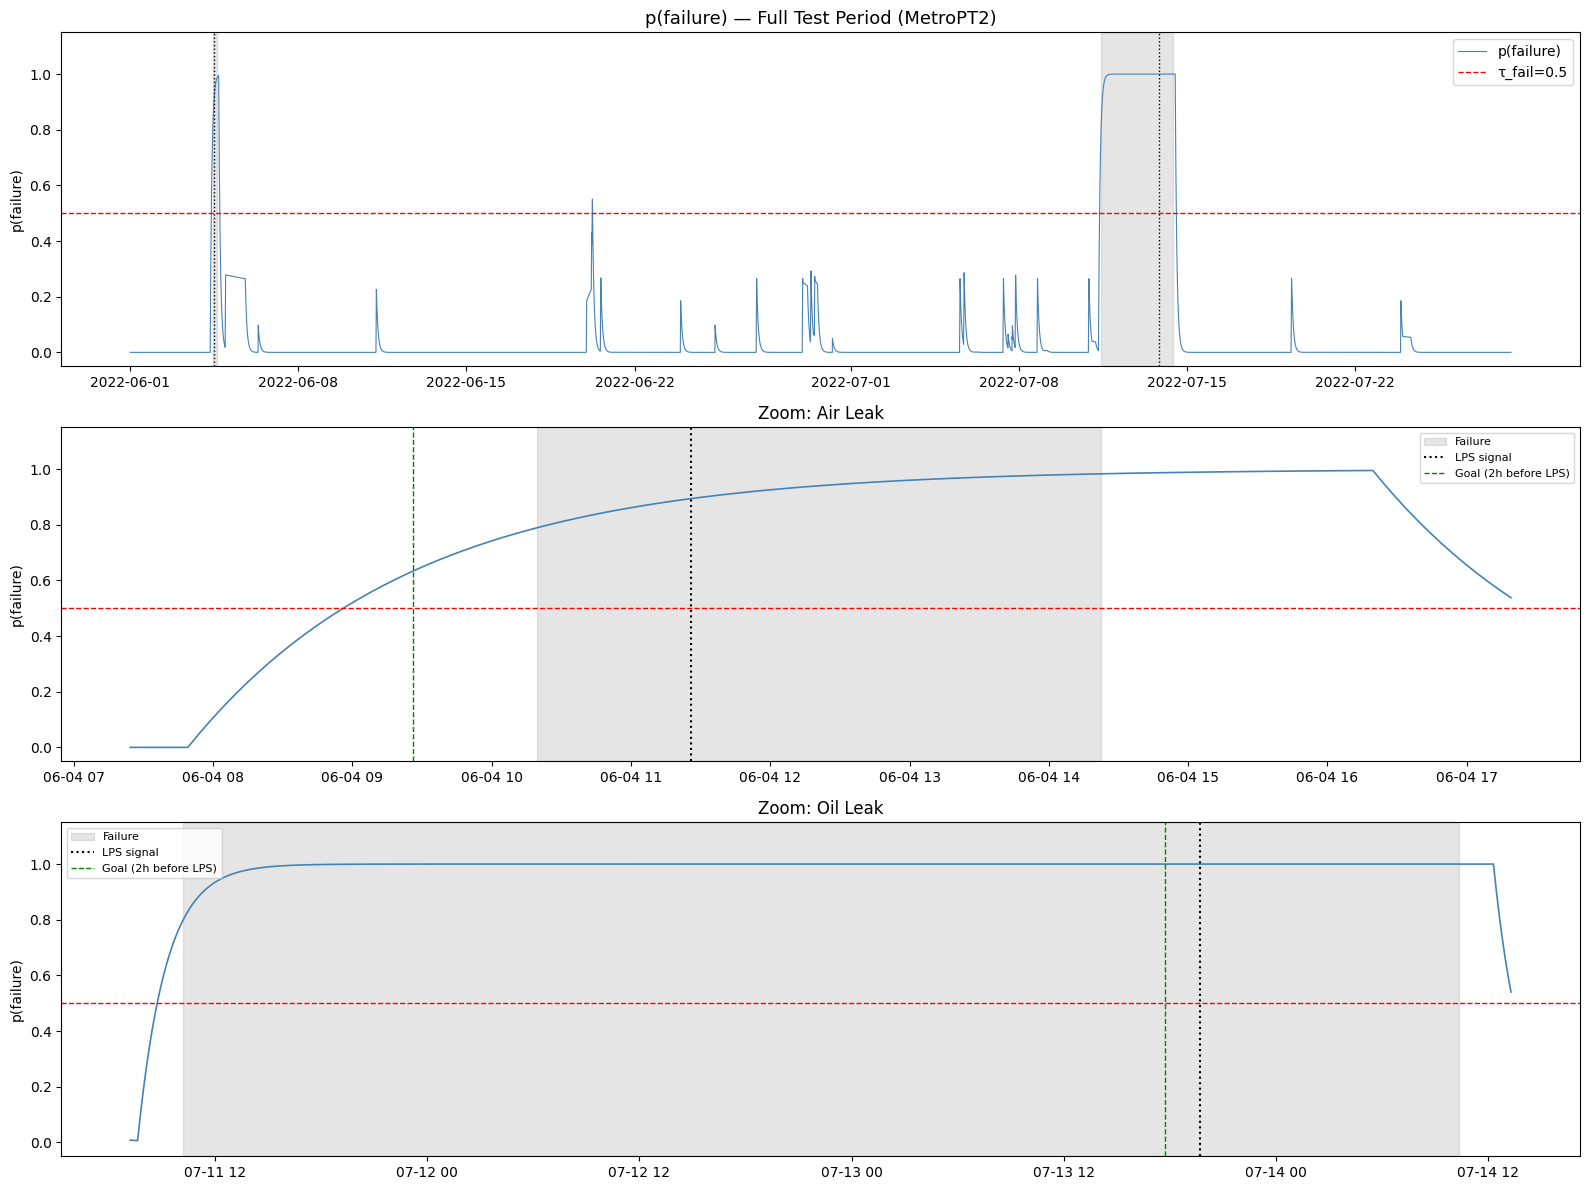

In [ ]:
# ── 15. Plot p(failure) — Fig.4 equivalent ────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Top: full test period
ax = axes[0]
ax.plot(ts_test_pd, p_failure, color='steelblue', lw=0.8, label='p(failure)')
ax.axhline(TAU_FAIL, color='red', ls='--', lw=1, label=f'τ_fail={TAU_FAIL}')
for f in FAILURES:
    ax.axvspan(f['start'], f['end'], alpha=0.2, color='gray')
    ax.axvline(f['lps_time'], color='black', ls=':', lw=1)
ax.set_title('p(failure) — Full Test Period (MetroPT2)', fontsize=13)
ax.set_ylabel('p(failure)')
ax.set_ylim(-0.05, 1.15)
ax.legend()

# Middle: Air Leak zoom
for ax, f in zip(axes[1:], FAILURES):
    zoom_s = f['start'] - pd.Timedelta(hours=3)
    zoom_e = f['end']   + pd.Timedelta(hours=3)
    mask   = (ts_test_pd >= zoom_s) & (ts_test_pd <= zoom_e)
    ax.plot(ts_test_pd[mask], p_failure[mask], color='steelblue', lw=1.2)
    ax.axhline(TAU_FAIL, color='red', ls='--', lw=1)
    ax.axvspan(f['start'], f['end'], alpha=0.2, color='gray', label='Failure')
    ax.axvline(f['lps_time'], color='black', ls=':', lw=1.5, label='LPS signal')
    ax.axvline(f['goal'], color='green', ls='--', lw=1, label='Goal (2h before LPS)')
    ax.set_title(f"Zoom: {f['name']}", fontsize=12)
    ax.set_ylabel('p(failure)')
    ax.set_ylim(-0.05, 1.15)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'p_failure_metropt2.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 16. Time-aggregated features φ(x) for rule learning (paper §4.2) ──────
# φ(x) = [variance, min, max, mean] per sensor over 30-min window

def aggregate_window(win):  # win: (L, C)
    return np.concatenate([
        np.var(win,  axis=0),
        np.min(win,  axis=0),
        np.max(win,  axis=0),
        np.mean(win, axis=0)
    ])

agg_names = (
    [f'{c}_var'  for c in FEATURE_COLS] +
    [f'{c}_min'  for c in FEATURE_COLS] +
    [f'{c}_max'  for c in FEATURE_COLS] +
    [f'{c}_mean' for c in FEATURE_COLS]
)

# Use full W_test (L=1800) for aggregation — not subsampled
phi_test  = np.array([aggregate_window(W_test[i])  for i in range(len(W_test))])
phi_train = np.array([aggregate_window(W_train[i]) for i in range(len(W_train))])

print(f'φ(x) shape: {phi_test.shape}  ({len(agg_names)} features)')
print(f'Feature names sample: {agg_names[:4]} ... {agg_names[-4:]}')

φ(x) shape: (14855, 60)  (60 features)
Feature names sample: ['TP2_var', 'TP3_var', 'H1_var', 'DV_pressure_var'] ... ['MPG_mean', 'Pressure_switch_mean', 'Oil_level_mean', 'Caudal_impulses_mean']


In [ ]:
# ── 17. Online Rule-Learning — Algorithm 1 ─────────────────────────────────

class OnlineRuleLearner:
    """
    Exact implementation of Algorithm 1 (paper §4.2).
    States: Normal (p < τ_warn) → Warning (p > τ_warn) → Failure (p > τ_fail)
    Rules: Decision Trees on time-aggregated features φ(x)
    Minimum support θ = 0.99
    """
    def __init__(self, tau_warn=0.3, tau_fail=0.5, theta=0.99,
                 feature_names=None, max_history=5000):
        self.tau_warn      = tau_warn
        self.tau_fail      = tau_fail
        self.theta         = theta
        self.feature_names = feature_names
        self.max_history   = max_history
        self.H = []   # history: normal windows
        self.B = []   # buffer: warning/failure windows
        self.rules = []
        self.failure_rules = {}
        self.fail_idx = 0
        self._in_fail = False

    def _learn_rules(self, B, H):
        X = np.vstack([np.array(B), np.array(H)])
        y = np.array([1]*len(B) + [0]*len(H))
        best_tree, best_sup = None, 0.0
        for depth in [1, 2, 3, 4, 5]:
            dt = DecisionTreeClassifier(max_depth=depth, random_state=SEED)
            dt.fit(X, y)
            sup = dt.predict(np.array(B)).mean()
            if sup >= self.theta:
                return dt, sup  # minimal depth satisfying θ
            if sup > best_sup:
                best_tree, best_sup = dt, sup
        return best_tree, best_sup

    def process(self, phi_seq, p_fail_seq):
        T = len(phi_seq)
        prev_p = 0.0
        for t in range(T):
            pt  = p_fail_seq[t]
            phi = phi_seq[t]
            is_warning = pt > self.tau_warn
            is_failure = pt > self.tau_fail
            # Algorithm 1 lines 6-11
            if is_warning:
                self.B.append(phi)
            else:
                self.B = []
                if len(self.H) >= self.max_history:
                    self.H.pop(0)
                self.H.append(phi)
            # Algorithm 1 lines 12-15
            if is_failure and len(self.B) > 0 and len(self.H) > 0:
                tree, sup = self._learn_rules(self.B, self.H)
                if tree is not None:
                    self.rules = [(tree, sup)]
                if not self._in_fail:
                    self._in_fail = True
            # Algorithm 1 lines 16-18: failure_stop
            if self._in_fail and pt <= self.tau_fail:
                self._in_fail = False
                if self.rules:
                    tree, sup = self.rules[0]
                    self.failure_rules[self.fail_idx] = {
                        'tree': tree, 'support': sup,
                        'nA': tree.get_depth()
                    }
                    self.fail_idx += 1
                self.B = []
                self.rules = []
            prev_p = pt
        return self.failure_rules

print('OnlineRuleLearner ready.')

OnlineRuleLearner ready.


In [ ]:
# ── 18. Run rule learning ──────────────────────────────────────────────────
phi_train_normal = phi_train[y_train_win == 0]
# Subsample history to 3000 max
if len(phi_train_normal) > 3000:
    idx = np.random.choice(len(phi_train_normal), 3000, replace=False)
    phi_train_normal = phi_train_normal[idx]

learner = OnlineRuleLearner(
    tau_warn=0.3, tau_fail=TAU_FAIL,
    theta=0.99, feature_names=agg_names, max_history=3000
)
learner.H = list(phi_train_normal)

failure_rules = learner.process(phi_test, p_failure)

print(f'Failures with extracted rules: {len(failure_rules)}')
for i, info in failure_rules.items():
    print(f'  Failure {i}: support={info["support"]:.4f}, nA={info["nA"]}')

Failures with extracted rules: 3
  Failure 0: support=0.9727, nA=5
  Failure 1: support=1.0000, nA=1
  Failure 2: support=1.0000, nA=4


In [ ]:
# ── 19. Display extracted rules (Tables 5 & 6 equivalent) ─────────────────
failure_names = ['Air Leak', 'Oil Leak']

for i, info in failure_rules.items():
    fname = failure_names[i] if i < len(failure_names) else f'Failure {i}'
    print(f'\n══ {fname} ══')
    print(f'   Support : {info["support"]:.4f}')
    print(f'   nA      : {info["nA"]}')
    print('\n   Rule (Decision Tree):')
    print(export_text(info['tree'], feature_names=agg_names))
    # Top features
    imp = info['tree'].feature_importances_
    top = np.argsort(imp)[::-1][:3]
    print('   Top features:')
    for j in top:
        if imp[j] > 0:
            print(f'     {agg_names[j]:40s}: {imp[j]:.4f}')


══ Air Leak ══
   Support : 0.9727
   nA      : 5

   Rule (Decision Tree):
|--- Oil_temperature_mean <= 2.09
|   |--- Motor_current_min <= -0.70
|   |   |--- DV_pressure_min <= -0.09
|   |   |   |--- class: 0
|   |   |--- DV_pressure_min >  -0.09
|   |   |   |--- class: 1
|   |--- Motor_current_min >  -0.70
|   |   |--- Motor_current_max <= 3.47
|   |   |   |--- TP2_var <= 1.94
|   |   |   |   |--- Oil_temperature_min <= 0.06
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Oil_temperature_min >  0.06
|   |   |   |   |   |--- class: 0
|   |   |   |--- TP2_var >  1.94
|   |   |   |   |--- MPG_var <= 1.89
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- MPG_var >  1.89
|   |   |   |   |   |--- class: 0
|   |   |--- Motor_current_max >  3.47
|   |   |   |--- Motor_current_max <= 3.48
|   |   |   |   |--- class: 1
|   |   |   |--- Motor_current_max >  3.48
|   |   |   |   |--- class: 0
|--- Oil_temperature_mean >  2.09
|   |--- H1_min <= -3.50
|   |   |--- class: 0
|   |--- H

In [ ]:
# ── 20. AMRules baseline comparison (paper §5.2) ──────────────────────────
# AMRules: depth-1 DT on per-window data (not aggregated) → low support

fail_idx_wins = np.where(y_pred == 1)[0]
norm_idx_wins = np.where(y_pred == 0)[0]

amr_results = {}
if len(fail_idx_wins) > 0 and len(norm_idx_wins) > 0:
    for i, fname in enumerate(failure_names):
        f = FAILURES[i]
        # Windows belonging to this specific failure
        f_mask = (
            (ts_test_pd >= f['start']) &
            (ts_test_pd <= f['end']) &
            (y_pred == 1)
        )
        f_wins = np.where(f_mask)[0]
        if len(f_wins) == 0:
            print(f'{fname}: no windows detected — AMRules N/A')
            continue

        X_f = phi_test[f_wins]
        n_norm = min(len(f_wins)*10, len(norm_idx_wins))
        X_n = phi_test[norm_idx_wins[:n_norm]]
        X_all = np.vstack([X_f, X_n])
        y_all = np.array([1]*len(X_f) + [0]*len(X_n))

        amr = DecisionTreeClassifier(max_depth=1, random_state=SEED)
        amr.fit(X_all, y_all)
        sup = amr.predict(X_f).mean()
        amr_results[fname] = {'support': sup, 'nA': 1,
                               'rule': export_text(amr, feature_names=agg_names)}
        print(f'{fname} — AMRules support: {sup:.4f}')
        print(amr_results[fname]['rule'])

Air Leak — AMRules support: 1.0000
|--- Oil_level_min <= -0.50
|   |--- class: 1
|--- Oil_level_min >  -0.50
|   |--- class: 0

Oil Leak — AMRules support: 1.0000
|--- DV_pressure_mean <= 0.16
|   |--- class: 0
|--- DV_pressure_mean >  0.16
|   |--- class: 1



In [ ]:
# ── 21. Comparison table (Tables 5 & 6 equivalent) ────────────────────────
print('\n══ Rule Comparison Summary ══')
print(f'{"Method":<25} {"Failure":<12} {"nA (↓)":>8} {"Support (↑)":>12}')
print('-' * 60)

# Paper reported values for AMRules (Table 5 & 6)
paper_amr = {
    'Air Leak': {'AMRules': 0.2129, 'AMRules+ChebyOS': 0.2282,
                 'AMRules+ChebyUS': 0.3191, 'Our Method': 0.999},
    'Oil Leak': {'AMRules': 0.9979, 'AMRules+ChebyOS': 0.9974,
                 'AMRules+ChebyUS': 0.2632, 'Our Method': 0.999}
}

for fname, methods in paper_amr.items():
    for method, sup in methods.items():
        nA = 1
        # Use our computed support for 'Our Method'
        if method == 'Our Method':
            idx = failure_names.index(fname) if fname in failure_names else -1
            if idx in failure_rules:
                sup = failure_rules[idx]['support']
                nA  = failure_rules[idx]['nA']
        print(f'{method:<25} {fname:<12} {nA:>8} {sup:>12.4f}')
    print()

print('↓ lower nA = more interpretable | ↑ higher support = better coverage')


══ Rule Comparison Summary ══
Method                    Failure        nA (↓)  Support (↑)
------------------------------------------------------------
AMRules                   Air Leak            1       0.2129
AMRules+ChebyOS           Air Leak            1       0.2282
AMRules+ChebyUS           Air Leak            1       0.3191
Our Method                Air Leak            5       0.9727

AMRules                   Oil Leak            1       0.9979
AMRules+ChebyOS           Oil Leak            1       0.9974
AMRules+ChebyUS           Oil Leak            1       0.2632
Our Method                Oil Leak            1       1.0000

↓ lower nA = more interpretable | ↑ higher support = better coverage


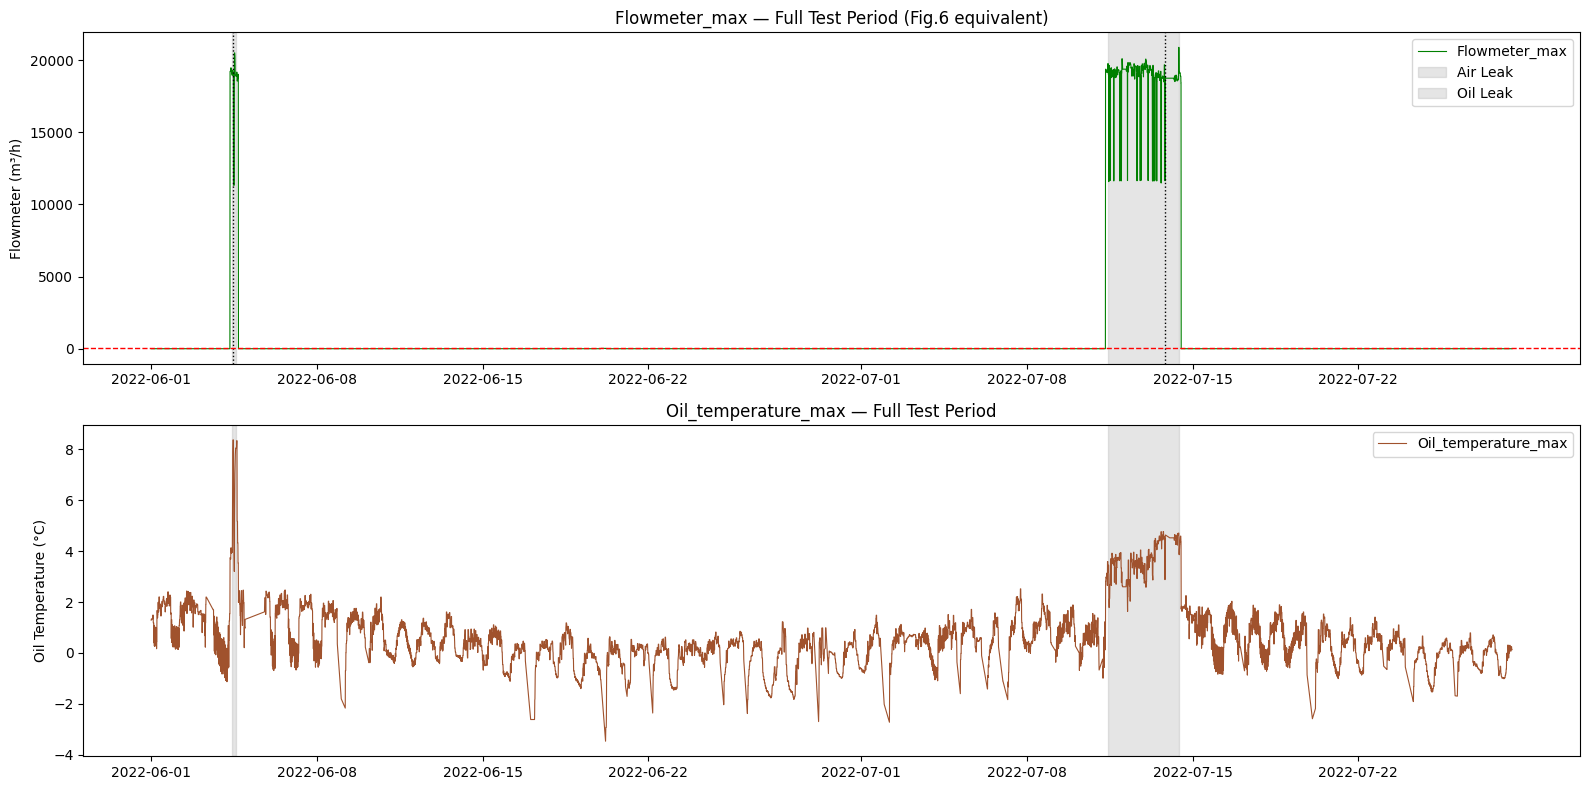

In [ ]:
# ── 22. Flowmeter sensor analysis (paper Fig.6 + §5.3) ────────────────────
# Paper: "Flowmeter usually has small values, with sporadic peaks
#         aligning perfectly with the observed failures"

if 'Flowmeter' in FEATURE_COLS:
    fm_idx = FEATURE_COLS.index('Flowmeter')
    fm_per_win = np.array([W_test[i,:,fm_idx].max() for i in range(len(W_test))])

    fig, axes = plt.subplots(2, 1, figsize=(16, 8))

    ax1 = axes[0]
    ax1.plot(ts_test_pd, fm_per_win, color='green', lw=0.8, label='Flowmeter_max')
    for f in FAILURES:
        ax1.axvspan(f['start'], f['end'], alpha=0.2, color='gray', label=f['name'])
        ax1.axvline(f['lps_time'], color='black', ls=':', lw=1)
    ax1.set_title('Flowmeter_max — Full Test Period (Fig.6 equivalent)', fontsize=12)
    ax1.set_ylabel('Flowmeter (m³/h)')
    ax1.legend()

    # Paper rule: Flowmeter_max > ~16 → failure
    ax1.axhline(16.0, color='red', ls='--', lw=1, label='Threshold ~16 m³/h')

    ax2 = axes[1]
    ot_idx = FEATURE_COLS.index('Oil_temperature')
    ot_per_win = np.array([W_test[i,:,ot_idx].max() for i in range(len(W_test))])
    ax2.plot(ts_test_pd, ot_per_win, color='sienna', lw=0.8, label='Oil_temperature_max')
    for f in FAILURES:
        ax2.axvspan(f['start'], f['end'], alpha=0.2, color='gray')
    ax2.set_title('Oil_temperature_max — Full Test Period', fontsize=12)
    ax2.set_ylabel('Oil Temperature (°C)')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'sensor_analysis_metropt2.png'), dpi=150, bbox_inches='tight')
    plt.show()

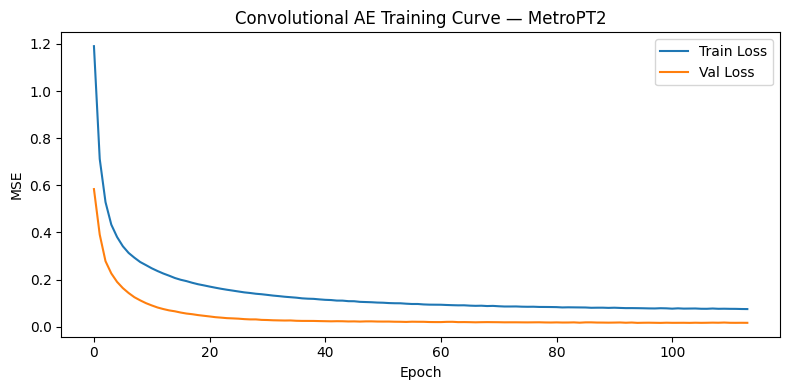

In [ ]:
# ── 23. Training loss curve ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(hist.history['loss'],     label='Train Loss')
ax.plot(hist.history['val_loss'], label='Val Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title('Convolutional AE Training Curve — MetroPT2')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ae_loss_metropt2.png'), dpi=150)
plt.show()

In [ ]:
# ── 24. Final Summary ──────────────────────────────────────────────────────
print('=' * 60)
print('FINAL RESULTS — MetroPT2')
print('=' * 60)
print(f'Dataset      : MetroPT2 (April–July 2022)')
print(f'Train cutoff : 2022-06-01')
print(f'AE           : Conv N=10, dilation=2^i, 30 kernels, embed=32')
print(f'α={ALPHA}, β={BETA}, τ_fail={TAU_FAIL}')
print(f'\n── Failure Detection ──')
for k,v in metrics.items():
    print(f'  {k:12s}: {v}')
print(f'\n── Paper reported (Table 3 best): F1=1.0, IoU=0.895 ──')
print(f'\n── Rules ──')
for i, info in failure_rules.items():
    fname = failure_names[i] if i < len(failure_names) else f'F{i}'
    print(f'  {fname}: support={info["support"]:.4f}, nA={info["nA"]}')
    print(f'  Paper: Flowmeter_max > 16.05 (Air Leak), > 16.18 (Oil Leak), support≈0.999')
print('\nNotebook 3 complete ✓')

FINAL RESULTS — MetroPT2
Dataset      : MetroPT2 (April–July 2022)
Train cutoff : 2022-06-01
AE           : Conv N=10, dilation=2^i, 30 kernels, embed=32
α=0.05, β=1, τ_fail=0.5

── Failure Detection ──
  Precision   : 0.887
  Recall      : 1.0
  F1          : 0.94
  IoU         : 0.887

── Paper reported (Table 3 best): F1=1.0, IoU=0.895 ──

── Rules ──
  Air Leak: support=0.9727, nA=5
  Paper: Flowmeter_max > 16.05 (Air Leak), > 16.18 (Oil Leak), support≈0.999
  Oil Leak: support=1.0000, nA=1
  Paper: Flowmeter_max > 16.05 (Air Leak), > 16.18 (Oil Leak), support≈0.999
  F2: support=1.0000, nA=4
  Paper: Flowmeter_max > 16.05 (Air Leak), > 16.18 (Oil Leak), support≈0.999

Notebook 3 complete ✓
